# Project 1: Image Denoising using Autoencoder on MNIST

### This project builds a Deep Learning Autoencoder that removes noise from handwritten digit images using the MNIST dataset.

## Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Flatten,
    Reshape
)
from tensorflow.keras.optimizers import Adam

## Load MNIST Dataset

In [2]:
(x_train, _), (x_test, _) = mnist.load_data()

## Normalize Images

In [3]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

## Reshape Images

MNIST images are:

28 × 28

In [4]:
#Flatten them into vectors:
x_train_flat = x_train.reshape(
    (len(x_train), 28 * 28)
)
x_test_flat = x_test.reshape(
    (len(x_test), 28 * 28)
)

## Add Noise to Images

In [5]:
noise_factor = 0.5
x_train_noisy = x_train_flat + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train_flat.shape
)
x_test_noisy = x_test_flat + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test_flat.shape
)

In [6]:
x_train_noisy = np.clip(
    x_train_noisy,
    0.,
    1.
)
x_test_noisy = np.clip(
    x_test_noisy,
    0.,
    1.
)

## Visualize Noisy Images

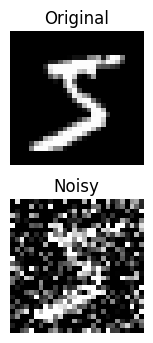

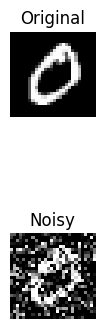

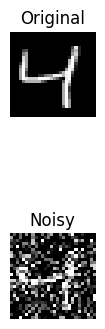

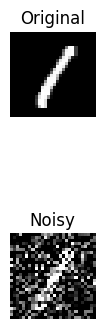

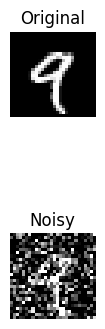

In [7]:
plt.figure(figsize=(10,4))
for i in range(5):
  plt.subplot(2,5,i+1)
  plt.imshow(
      x_train_flat[i].reshape(28,28),
      cmap='gray'
      )
  plt.title("Original")
  plt.axis('off')
  plt.subplot(2,5,i+6)
  plt.imshow(
      x_train_noisy[i].reshape(28,28),
      cmap='gray'
      )
  plt.title("Noisy")
  plt.axis('off')
  plt.show()

## Build Autoencoder

The encoder compresses the noisy image into a lower-dimensional representation,
while the decoder reconstructs the clean image from compressed features.

### Encoder

In [8]:
input_img = Input(shape=(784,))

In [9]:
encoded = Dense(
    128,
    activation='relu'
)(input_img)
encoded = Dense(
    64,
    activation='relu'
)(encoded)
encoded = Dense(
    32,
    activation='relu'
)(encoded)

### Decoder

In [10]:
decoded = Dense(
    64,
    activation='relu'
)(encoded)
decoded = Dense(
    128,
    activation='relu'
)(decoded)
decoded = Dense(
    784,
    activation='sigmoid'
)(decoded)

## Create Autoencoder Model

In [11]:
autoencoder = Model(
    input_img,
    decoded
)

## Compile Model

In [12]:
autoencoder.compile(
    optimizer=Adam(),
    loss='binary_crossentropy'
)

## EarlyStopping

It:
* monitors validation loss
* stops training automatically if model stops improving
* prevents overfitting
* restores best weights automatically

In [13]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

## Model Summary

In [14]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

## Train Autoencoder

In [15]:
history = autoencoder.fit(
    x_train_noisy,
    x_train_flat,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(
        x_test_noisy,
        x_test_flat
    ),
    callbacks=[early_stop]
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - loss: 0.2651 - val_loss: 0.2090
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1866 - val_loss: 0.1707
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1666 - val_loss: 0.1608
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.1578 - val_loss: 0.1535
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.1523 - val_loss: 0.1491
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1481 - val_loss: 0.1451
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1443 - val_loss: 0.1417
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.1410 - val_loss: 0.1390
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.1384 - val_loss: 0.1368
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1360 - val_loss: 0.1347
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1341 - val_loss: 0.1335
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 

## Model Evaluation Loss

In [16]:
test_loss = autoencoder.evaluate(
    x_test_noisy,
    x_test_flat
)
print("Test Loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1257
Test Loss: 0.12574094533920288


## Predict Denoised Images

In [17]:
decoded_imgs = autoencoder.predict(
    x_test_noisy
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


## Visualize Results

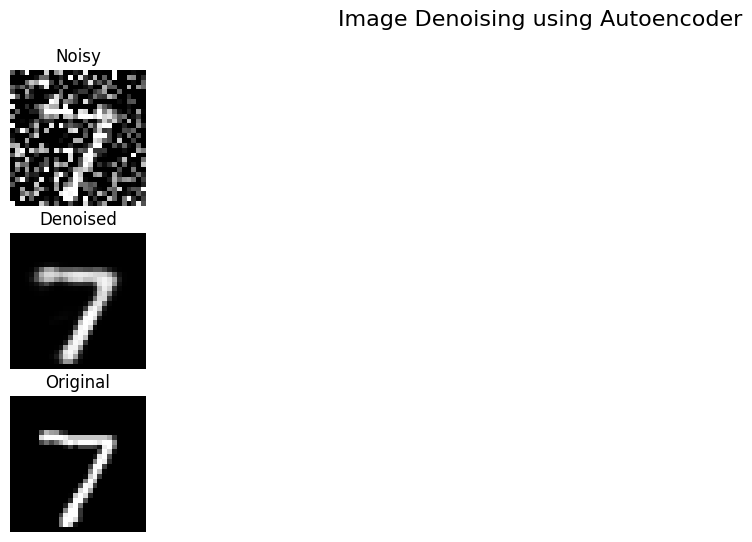

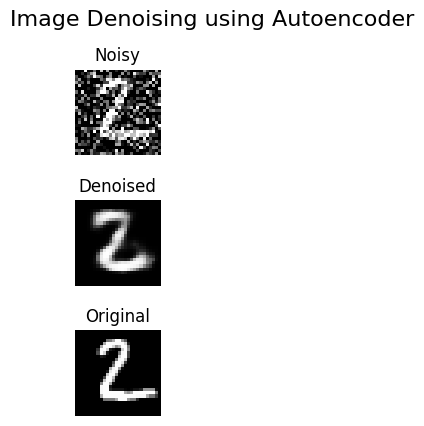

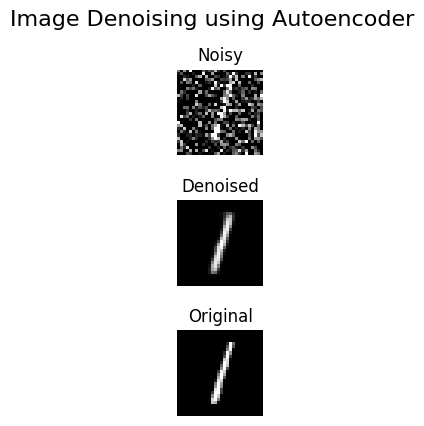

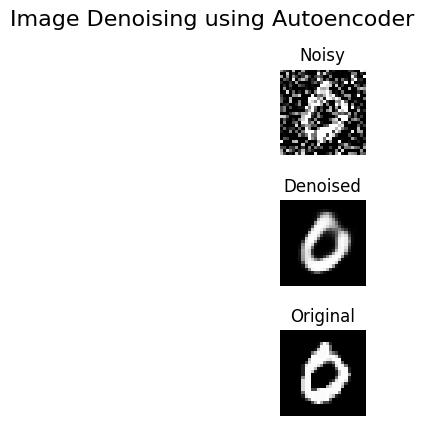

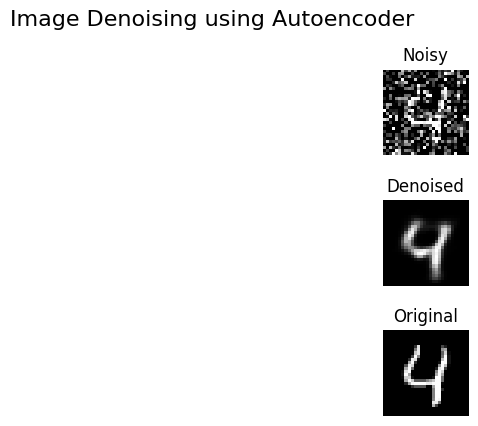

In [18]:
n = 5
plt.figure(figsize=(15,6))
for i in range(n):
  # Noisy Image
  plt.subplot(3,n,i+1)
  plt.imshow(
      x_test_noisy[i].reshape(28,28),
      cmap='gray'
    )
  plt.title("Noisy")
  plt.axis('off')
  # Denoised Image
  plt.subplot(3,n,i+n+1)
  plt.imshow(
      decoded_imgs[i].reshape(28,28),
      cmap='gray'
      )
  plt.title("Denoised")
  plt.axis('off')
  # Original Image
  plt.subplot(3,n,i+2*n+1)
  plt.imshow(
      x_test_flat[i].reshape(28,28),
      cmap='gray'
  )
  plt.title("Original")
  plt.axis('off')
  plt.suptitle(
    "Image Denoising using Autoencoder",
    fontsize=16
  )
  plt.show()

## Plot Training Loss

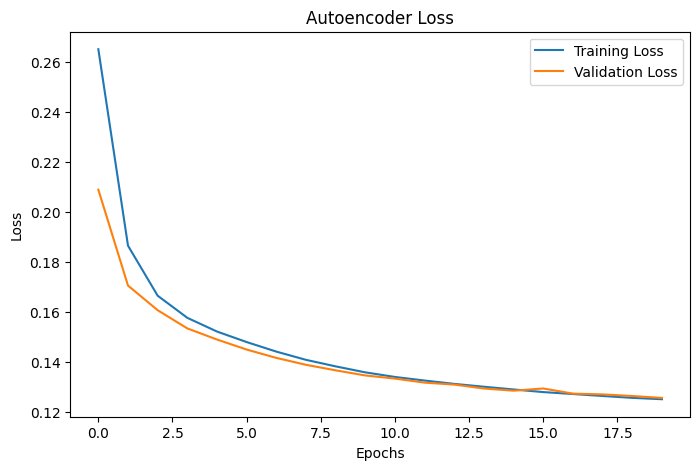

In [19]:
plt.figure(figsize=(8,5))
plt.plot(
    history.history['loss'],
    label='Training Loss'
)
plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Autoencoder Loss")
plt.legend()
plt.show()

# Conclusion:
* Autoencoder successfully learned compressed image representations.
* Noise was effectively removed from MNIST digit images.
* Encoder extracted important features from noisy inputs.
* Decoder reconstructed cleaner images.
* Deep learning autoencoders are effective for image denoising tasks.

## Project Summary

In [20]:
print("""
Project Summary

Dataset: MNIST
Model: Deep Autoencoder
Task: Image Denoising
Optimizer: Adam
Loss Function: Binary Crossentropy
Epochs: 20
""")


Project Summary

Dataset: MNIST
Model: Deep Autoencoder
Task: Image Denoising
Optimizer: Adam
Loss Function: Binary Crossentropy
Epochs: 20



## Experiment Observation

In [21]:
print("""
Experiment Observation

Noise Factor 0.3:
- Easier reconstruction
- Cleaner outputs

Noise Factor 0.5:
- Moderate denoising performance

Noise Factor 0.7:
- Harder reconstruction
- Some digit details lost
""")


Experiment Observation

Noise Factor 0.3:
- Easier reconstruction
- Cleaner outputs

Noise Factor 0.5:
- Moderate denoising performance

Noise Factor 0.7:
- Harder reconstruction
- Some digit details lost

